# Dual-View SARF GATED Stratified K-Fold Cross-Validation
Dual-View gated architecture (shared XLM-RoBERTa large encoder over surface + lemma,
cross-attention, learned per-token fusion gate, CNN + BiLSTM head) with fixed
hyperparameters found via Optuna HPO. The gate replaces the
fixed 50/50 surface/lemma average with a weight learned from data; everything else is
identical to `kusa_dual_view_cv`.

Cross-validation runs on the entire dataset via Stratified K-Fold, every sample is
predicted exactly once out-of-fold. No test set is locked away.

**Limitations:** The hyperparameters were selected on a 20% validation split of the same data
that this cross-validation runs over, so the reported CV score carries a mild optimistic bias.
A fully unbiased estimate would require nested cross-validation, which was deliberately omitted
for compute-time reasons.


# Dependencies and imports

In [ ]:
!pip install -q transformers sentencepiece accelerate

In [ ]:
import re
import copy
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from transformers import AutoModelForSequenceClassification, AutoTokenizer, get_linear_schedule_with_warmup
from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.metrics import f1_score, classification_report, confusion_matrix, ConfusionMatrixDisplay
from tqdm import tqdm
import torch.optim as optim
import matplotlib.pyplot as plt
import random
from google.colab import drive
import os
import urllib.request
import json
import torch.nn.functional as F


# Globals and parameters

In [ ]:
drive.mount('/content/drive')

import urllib.request
import json

# Finding notebook name
try:
    req = urllib.request.urlopen('http://172.28.0.12:9000/api/sessions')
    sessions = json.loads(req.read())
    file_name = sessions[0]['name']
    NOTEBOOK_NAME = os.path.splitext(file_name)[0]
except Exception:
    NOTEBOOK_NAME = "kusa_dual_view_gated_cv"

print(f"Aktiver Notebook-Name: {NOTEBOOK_NAME}")

DIR_PATH                    = "/content/drive/MyDrive/google_colab/kusa"
DATA_PATH                   = DIR_PATH + "/datasets"
SAVE_DIR                    = DIR_PATH + "/" + NOTEBOOK_NAME

# preprocessed CSV
PREPROCESSED_KURDISENT_PATH = DATA_PATH + "/KurdiSent_preprocessed.csv"

os.makedirs(SAVE_DIR, exist_ok=True)

Mounted at /content/drive
Aktiver Notebook-Name: kusa_dual_view_gated_cv


In [ ]:
BERT_MODEL_NAME         = "xlm-roberta-large"

# Fixed settings
EPOCHS                  = 8
PATIENCE                = 3
MAX_LEN                 = 128

# CV
N_FOLDS                 = 5

In [ ]:
# Optuna Hyperparameters
BATCH_SIZE     = 16
ENCODER_LR     = 5e-06
HEAD_LR        = 0.001
WEIGHT_DECAY   = 0.0
WARMUP_RATIO   = 0.2
DROPOUT        = 0.3

print("CV hyperparameters in use:")
print(f"  BATCH_SIZE    = {BATCH_SIZE}")
print(f"  ENCODER_LR    = {ENCODER_LR}")
print(f"  HEAD_LR       = {HEAD_LR}")
print(f"  WEIGHT_DECAY  = {WEIGHT_DECAY}")
print(f"  WARMUP_RATIO  = {WARMUP_RATIO}")
print(f"  DROPOUT       = {DROPOUT}")


CV hyperparameters in use:
  BATCH_SIZE    = 16
  ENCODER_LR    = 5e-06
  HEAD_LR       = 0.001
  WEIGHT_DECAY  = 0.0
  WARMUP_RATIO  = 0.2
  DROPOUT       = 0.3


In [ ]:
# Same seed for reproducibility
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

# Data preprocessing

In [ ]:
df = pd.read_csv(PREPROCESSED_KURDISENT_PATH, encoding='utf-8')
df = df.loc[:, ~df.columns.str.contains('^Unnamed')]
# Dual-View needs both views
df = df.dropna(subset=['surface', 'lemma']).reset_index(drop=True)

print(f"Dataset loaded: {len(df)} samples")
print(df['label'].value_counts().sort_index())


Dataset loaded: 12306 samples
label
0    4102
1    4102
2    4102
Name: count, dtype: int64


In [ ]:
# Cross-validation runs over the ENTIRE dataset
cv_df = df.reset_index(drop=True)

print(f"Full dataset used for CV (100%): {len(cv_df)}")


Full dataset used for CV (100%): 12306


# Architecture

In [ ]:
# Dual-View architecture: shared XLM-R encoder over surface + lemma,
# cross-attention, CNN + BiLSTM fusion head.

class DualViewSurfaceLemmaDataset(Dataset):
    """
    PyTorch Dataset for the dual-view approach (Surface + Lemma).

    Each sample contains two tokenized variants of the same sentence:
      - surface: Normalized original text.
      - lemma:   Lemmatized words to reduce morphological variance.

    Both views are independently tokenized and padded/truncated to max_len.
    """

    def __init__(self, df, tokenizer, max_len=MAX_LEN):
        self.surface   = df["surface"].tolist()
        self.lemma     = df["lemma"].tolist()
        self.labels    = df["label"].tolist()
        self.tokenizer = tokenizer
        self.max_len   = max_len

    def __len__(self):
        return len(self.labels)

    def encode(self, text):
        """Tokenizes text and returns input_ids and attention_mask."""
        enc = self.tokenizer(
            text,
            padding="max_length",
            truncation=True,
            max_length=self.max_len,
            return_tensors="pt"
        )
        return {
            "input_ids":      enc["input_ids"].squeeze(0),
            "attention_mask": enc["attention_mask"].squeeze(0)
        }

    def __getitem__(self, idx):
        return {
            "surface": self.encode(self.surface[idx]),
            "lemma":   self.encode(self.lemma[idx]),
            "labels":  torch.tensor(self.labels[idx], dtype=torch.long),
        }


def dual_surface_lemma_collator(features):
    """Collates a list of samples into a batch."""
    batch = {}
    for key in ["surface", "lemma"]:
        batch[key] = {
            "input_ids":      torch.stack([f[key]["input_ids"]      for f in features]),
            "attention_mask": torch.stack([f[key]["attention_mask"] for f in features])
        }
    batch["labels"] = torch.stack([f["labels"] for f in features])
    return batch


class DualViewCNNBiLSTMAttention(nn.Module):
    """
    Dual-View SARF architecture for Kurdish (Sorani) sentiment analysis.

    Architecture Overview:
      1. Shared XLM-RoBERTa encoder independently encodes surface and lemma views.
      2. Cross-Attention: Surface representation queries lemma representation to
         integrate morphological base-form information.
      3. Fusion: Averages surface output and lemma attention output.
      4. CNN: Extracts local n-gram patterns from surface output (kernels 3/4/5).
      5. BiLSTM: Captures global sequence dependencies from the fused output.
      6. Classification: Concatenates CNN and BiLSTM features.
    """

    def __init__(
        self,
        bert_model_name="xlm-roberta-large",
        lstm_hidden_dim=128,
        cnn_filters=200,
        kernel_sizes=(3, 4, 5),
        num_classes=3,
        dropout=0.3
    ):
        super(DualViewCNNBiLSTMAttention, self).__init__()

        # Shared encoder for both views
        base_model = AutoModelForSequenceClassification.from_pretrained(
            bert_model_name, return_dict=True, num_labels=num_classes
        )
        self.encoder = base_model.roberta if hasattr(base_model, "roberta") else base_model.bert
        bert_hidden_dim = self.encoder.config.hidden_size

        # cross-attention surface attended to lemma
        self.cross_attn_lemma = nn.MultiheadAttention(
            embed_dim=bert_hidden_dim, num_heads=8, batch_first=True
        )

        # gated fusion a learned gate outputs a weight in [0,1] per token,
        # deciding how much surface vs. lemma information to keep at each position
        self.fusion_gate = nn.Linear(bert_hidden_dim * 2, 1)

        # CNN local features from surface output
        self.convs = nn.ModuleList([
            nn.Conv2d(
                in_channels=1,
                out_channels=cnn_filters,
                kernel_size=(k, bert_hidden_dim)
            )
            for k in kernel_sizes
        ])

        # BiLSTM global sequence features from the fused cross-attention
        self.bilstm = nn.LSTM(
            input_size=bert_hidden_dim,
            hidden_size=lstm_hidden_dim,
            num_layers=1,
            bidirectional=True,
            batch_first=True
        )

        # classification head CNN features + BiLSTM features -> num_classes logits
        fused_dim = (cnn_filters * len(kernel_sizes)) + (lstm_hidden_dim * 2)
        self.dropout = nn.Dropout(dropout)
        self.fc      = nn.Linear(fused_dim, num_classes)

    def forward(self, surface, lemma):
        surface_mask = surface["attention_mask"]
        lemma_mask   = lemma["attention_mask"]

        # Pass both views through the shared encoder
        surface_out = self.dropout(self.encoder(**surface).last_hidden_state)
        lemma_out   = self.dropout(self.encoder(**lemma).last_hidden_state)

        # cross-attention surface queries lemma
        lemma_key_padding_mask = (lemma_mask == 0)
        lemma_attn, _ = self.cross_attn_lemma(
            query=surface_out, key=lemma_out, value=lemma_out,
            key_padding_mask=lemma_key_padding_mask
        )

        # gated fusion per-token surface_weight in [0,1] from the gate
        concat_features = torch.cat((surface_out, lemma_attn), dim=-1)
        surface_weight  = torch.sigmoid(self.fusion_gate(concat_features))
        cross_attended  = (surface_weight * surface_out) + ((1.0 - surface_weight) * lemma_attn)

        # Zero out padding positions to exclude them from CNN/BiLSTM
        pad_mask_2d = (surface_mask == 0).unsqueeze(-1)
        cross_attended = cross_attended.masked_fill(pad_mask_2d, 0.0)
        cross_attended = self.dropout(cross_attended)

        # CNN on surface output
        pad_mask_4d = (surface_mask == 0).unsqueeze(1).unsqueeze(-1)
        cnn_input   = surface_out.unsqueeze(1).masked_fill(pad_mask_4d, 0.0)

        cnn_features = []
        for conv in self.convs:
            x = F.relu(conv(cnn_input)).squeeze(3)  # (batch, filters, seq_len - k + 1)
            x = F.max_pool1d(x, kernel_size=x.size(2)).squeeze(2)  # global max-pooling
            cnn_features.append(x)
        cnn_out = torch.cat(cnn_features, dim=1)  # (batch, filters * num_kernels)

        # BiLSTM on fused features (mean pooled)
        lengths      = surface_mask.sum(dim=1).cpu()
        packed_input = nn.utils.rnn.pack_padded_sequence(
            cross_attended, lengths, batch_first=True, enforce_sorted=False
        )
        packed_output, _ = self.bilstm(packed_input)
        lstm_out, _      = nn.utils.rnn.pad_packed_sequence(
            packed_output, batch_first=True, total_length=surface_mask.size(1)
        )

        # Mean-pooling over non-padding tokens
        input_mask_expanded = surface_mask.unsqueeze(-1).expand(lstm_out.size()).float()
        sum_embeddings = torch.sum(lstm_out * input_mask_expanded, dim=1)
        sum_mask       = torch.clamp(input_mask_expanded.sum(dim=1), min=1e-9)
        lstm_pooled    = sum_embeddings / sum_mask

        # Final feature vector CNN features and BiLSTM features -> classification
        fused  = torch.cat((cnn_out, lstm_pooled), dim=1)
        output = self.dropout(fused)
        logits = self.fc(output)
        return logits, surface_weight


In [ ]:
tokenizer = AutoTokenizer.from_pretrained(BERT_MODEL_NAME)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Train on: {device}")

config.json:   0%|          | 0.00/616 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/25.0 [00:00<?, ?B/s]

sentencepiece.bpe.model:   0%|          | 0.00/5.07M [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/9.10M [00:00<?, ?B/s]

Train on: cuda


# Training (one fold)

In [ ]:
def train_one_fold(fold, fold_train_df, fold_val_df, seed):
    # Per-fold reproducible seed
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

    train_loader = DataLoader(DualViewSurfaceLemmaDataset(fold_train_df, tokenizer),
                              batch_size=BATCH_SIZE, shuffle=True,
                              collate_fn=dual_surface_lemma_collator)
    val_loader   = DataLoader(DualViewSurfaceLemmaDataset(fold_val_df, tokenizer),
                              batch_size=BATCH_SIZE, shuffle=False,
                              collate_fn=dual_surface_lemma_collator)

    model = DualViewCNNBiLSTMAttention(
        bert_model_name=BERT_MODEL_NAME, num_classes=3, dropout=DROPOUT
    )
    model.to(device)

    # separate learning rates
    encoder_params = list(model.encoder.parameters())
    head_params    = [p for n, p in model.named_parameters() if "encoder" not in n]
    optimizer = optim.AdamW([
        {"params": encoder_params, "lr": ENCODER_LR},
        {"params": head_params,    "lr": HEAD_LR},
    ], weight_decay=WEIGHT_DECAY)

    total_steps  = len(train_loader) * EPOCHS
    warmup_steps = int(total_steps * WARMUP_RATIO)
    scheduler = get_linear_schedule_with_warmup(
        optimizer, num_warmup_steps=warmup_steps, num_training_steps=total_steps
    )
    criterion = nn.CrossEntropyLoss()

    best_val_f1 = 0.0
    best_state  = None
    patience_counter = 0

    for epoch in range(EPOCHS):
        model.train()
        total_train_loss = 0
        for batch in tqdm(train_loader, desc=f"Fold {fold+1} | Train Epoch {epoch+1}/{EPOCHS}", leave=False):
            surface = {k: v.to(device) for k, v in batch["surface"].items()}
            lemma   = {k: v.to(device) for k, v in batch["lemma"].items()}
            labels  = batch["labels"].to(device)

            optimizer.zero_grad()
            logits, _ = model(surface, lemma)
            loss    = criterion(logits, labels)
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            optimizer.step()
            scheduler.step()
            total_train_loss += loss.item()
        avg_train_loss = total_train_loss / len(train_loader)

        # validation
        model.eval()
        val_preds, val_labels_list, total_val_loss = [], [], 0
        with torch.no_grad():
            for batch in val_loader:
                surface = {k: v.to(device) for k, v in batch["surface"].items()}
                lemma   = {k: v.to(device) for k, v in batch["lemma"].items()}
                labels  = batch["labels"].to(device)
                logits, _ = model(surface, lemma)
                total_val_loss += criterion(logits, labels).item()
                preds = torch.argmax(logits, dim=1)
                val_preds.extend(preds.cpu().numpy())
                val_labels_list.extend(labels.cpu().numpy())
        avg_val_loss = total_val_loss / len(val_loader)
        val_f1 = f1_score(val_labels_list, val_preds, average='macro')

        print(f"Fold {fold+1} | Epoch {epoch+1}/{EPOCHS} | Train Loss: {avg_train_loss:.4f} | "
              f"Val Loss: {avg_val_loss:.4f} | Val F1 (Macro): {val_f1:.4f}")

        if val_f1 > best_val_f1:
            best_val_f1 = val_f1
            best_state  = copy.deepcopy(model.state_dict())
            patience_counter = 0
            print(f"--> New best for fold {fold+1} (F1: {best_val_f1:.4f})")
        else:
            patience_counter += 1
            print(f"--> No improvement. Patience: {patience_counter}/{PATIENCE}")
            if patience_counter >= PATIENCE:
                print(f"[!] Early stopping in fold {fold+1} after {epoch+1} epochs.")
                break

    # restore best weights
    if best_state is not None:
        model.load_state_dict(best_state)
        torch.save(best_state, os.path.join(SAVE_DIR, f"{NOTEBOOK_NAME}_fold{fold+1}_best.pth"))

    model.eval()
    fold_preds, fold_labels, fold_probs, fold_surface_w = [], [], [], []
    with torch.no_grad():
        for batch in val_loader:
            surface = {k: v.to(device) for k, v in batch["surface"].items()}
            lemma   = {k: v.to(device) for k, v in batch["lemma"].items()}
            labels  = batch["labels"].to(device)
            logits, surface_weight = model(surface, lemma)
            probs   = F.softmax(logits, dim=1)
            preds   = torch.argmax(logits, dim=1)

            # per-sample mean gate weight over non-padding tokens
            sw    = surface_weight.squeeze(-1)                      # (batch, seq)
            smask = surface["attention_mask"].float()              # (batch, seq)
            per_sample_sw = (sw * smask).sum(dim=1) / smask.sum(dim=1).clamp(min=1e-9)

            fold_probs.extend(probs.cpu().numpy().tolist())
            fold_preds.extend(preds.cpu().numpy())
            fold_labels.extend(labels.cpu().numpy())
            fold_surface_w.extend(per_sample_sw.cpu().numpy().tolist())

    del model, optimizer, scheduler
    torch.cuda.empty_cache()
    return best_val_f1, fold_preds, fold_labels, fold_probs, fold_surface_w


# Run K-Fold Cross-Validation

In [ ]:
skf = StratifiedKFold(n_splits=N_FOLDS, shuffle=True, random_state=SEED)

X = cv_df
y = cv_df["label"].values

fold_f1s = []
fold_surface_means = []
# oof buffers
oof_preds      = np.zeros(len(cv_df), dtype=int)
oof_labels     = np.zeros(len(cv_df), dtype=int)
oof_probs      = np.zeros((len(cv_df), 3), dtype=float)
oof_surface_w  = np.zeros(len(cv_df), dtype=float)   # gated-fusion surface share

for fold, (tr_idx, va_idx) in enumerate(skf.split(X, y)):
    print(f"\n{'='*60}\nFOLD {fold+1}/{N_FOLDS}\n{'='*60}")
    fold_train_df = cv_df.iloc[tr_idx].reset_index(drop=True)
    fold_val_df   = cv_df.iloc[va_idx].reset_index(drop=True)

    fold_seed = SEED + fold   # distinct, reproducible seed per fold
    best_f1, preds, labels, probs, sweights = train_one_fold(fold, fold_train_df, fold_val_df, fold_seed)

    fold_f1s.append(best_f1)
    fold_surface_means.append(float(np.mean(sweights)))
    oof_preds[va_idx]     = preds
    oof_labels[va_idx]    = labels
    oof_probs[va_idx]     = probs
    oof_surface_w[va_idx] = sweights
    print(f"\nFold {fold+1} best Val Macro-F1: {best_f1:.4f} | "
          f"mean surface weight: {np.mean(sweights)*100:.2f}%")


FOLD 1/5


model.safetensors:   0%|          | 0.00/2.24G [00:00<?, ?B/s]

Loading weights:   0%|          | 0/389 [00:00<?, ?it/s]

[transformers] XLMRobertaForSequenceClassification LOAD REPORT from: xlm-roberta-large
Key                         | Status     | 
----------------------------+------------+-
roberta.pooler.dense.weight | UNEXPECTED | 
lm_head.layer_norm.weight   | UNEXPECTED | 
lm_head.dense.bias          | UNEXPECTED | 
lm_head.layer_norm.bias     | UNEXPECTED | 
roberta.pooler.dense.bias   | UNEXPECTED | 
lm_head.dense.weight        | UNEXPECTED | 
lm_head.bias                | UNEXPECTED | 
classifier.out_proj.weight  | MISSING    | 
classifier.dense.bias       | MISSING    | 
classifier.out_proj.bias    | MISSING    | 
classifier.dense.weight     | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Fold 1 | Epoch 1/8 | Train Loss: 0.9615 | Val Loss: 0.6756 | Val F1 (Macro): 0.7123
--> New best for fold 1 (F1: 0.7123)


...

Fold 5 | Epoch 4/8 | Train Loss: 0.4708 | Val Loss: 0.5297 | Val F1 (Macro): 0.8104
--> No improvement. Patience: 1/3


Fold 5 | Epoch 5/8 | Train Loss: 0.4156 | Val Loss: 0.4812 | Val F1 (Macro): 0.8312
--> New best for fold 5 (F1: 0.8312)


Fold 5 | Epoch 6/8 | Train Loss: 0.3484 | Val Loss: 0.5302 | Val F1 (Macro): 0.8371
--> New best for fold 5 (F1: 0.8371)


Fold 5 | Epoch 7/8 | Train Loss: 0.3002 | Val Loss: 0.5257 | Val F1 (Macro): 0.8459
--> New best for fold 5 (F1: 0.8459)


Fold 5 | Epoch 8/8 | Train Loss: 0.2505 | Val Loss: 0.5159 | Val F1 (Macro): 0.8462
--> New best for fold 5 (F1: 0.8462)

Fold 5 best Val Macro-F1: 0.8462 | mean surface weight: 83.94%


# Cross-validation results

In [ ]:
fold_f1s = np.array(fold_f1s)
print("===== Per-fold best Validation Macro-F1 =====")
for i, f in enumerate(fold_f1s):
    print(f"  Fold {i+1}: {f:.4f}")
print("-" * 45)
print(f"  Mean : {fold_f1s.mean():.4f}")
print(f"  Std  : {fold_f1s.std():.4f}")
print(f"  Min  : {fold_f1s.min():.4f}")
print(f"  Max  : {fold_f1s.max():.4f}")

# Pooled out-of-fold report over the entire dataset
target_names = ["Neutral (0)", "Negative (1)", "Positive (2)"]
print("\n===== Pooled out-of-fold classification report (full dataset) =====")
print(classification_report(oof_labels, oof_preds, target_names=target_names, labels=[0, 1, 2]))

oof_macro_f1 = f1_score(oof_labels, oof_preds, average='macro')
print(f"Pooled OOF Macro-F1: {oof_macro_f1:.4f}")

# save summary
summary_path = os.path.join(SAVE_DIR, "cv_summary.csv")
pd.DataFrame({"fold": list(range(1, N_FOLDS + 1)), "val_macro_f1": fold_f1s}).to_csv(summary_path, index=False)
print(f"Saved per-fold summary to: {summary_path}")

===== Per-fold best Validation Macro-F1 =====
  Fold 1: 0.8574
  Fold 2: 0.8505
  Fold 3: 0.8586
  Fold 4: 0.8366
  Fold 5: 0.8462
---------------------------------------------
  Mean : 0.8499
  Std  : 0.0081
  Min  : 0.8366
  Max  : 0.8586

===== Pooled out-of-fold classification report (full dataset) =====
              precision    recall  f1-score   support

 Neutral (0)       0.76      0.87      0.81      4102
Negative (1)       0.90      0.84      0.87      4102
Positive (2)       0.91      0.84      0.87      4102

    accuracy                           0.85     12306
   macro avg       0.86      0.85      0.85     12306
weighted avg       0.86      0.85      0.85     12306

Pooled OOF Macro-F1: 0.8499
Saved per-fold summary to: /content/drive/MyDrive/google_colab/kusa/kusa_dual_view_gated_cv/cv_summary.csv


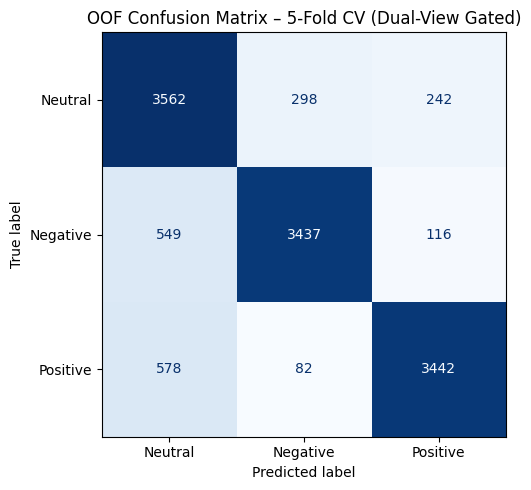

In [ ]:
# oof confusion matrix
cm   = confusion_matrix(oof_labels, oof_preds, labels=[0, 1, 2])
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Neutral', 'Negative', 'Positive'])
fig, ax = plt.subplots(figsize=(6, 5))
disp.plot(ax=ax, colorbar=False, cmap='Blues')
ax.set_title(f'OOF Confusion Matrix – {N_FOLDS}-Fold CV (Dual-View Gated)')
plt.tight_layout()
plt.savefig(os.path.join(SAVE_DIR, 'cv_oof_confusion_matrix.png'), dpi=150)
plt.show()

# Gated fusion – surface/lemma weighting


In [ ]:
# Out-of-fold analysis of the learned fusion gate

print("===== Per-fold mean surface weight =====")
for i, m in enumerate(fold_surface_means):
    print(f"  Fold {i+1}: surface {m*100:5.2f}%  |  lemma {(1-m)*100:5.2f}%")

oof_surface_mean = float(oof_surface_w.mean())
oof_lemma_mean   = 1.0 - oof_surface_mean
print("\n===== Overall view weighting (OOF, gated fusion) =====")
print(f"  Surface (original text): {oof_surface_mean*100:.2f} %")
print(f"  Lemma view             : {oof_lemma_mean*100:.2f} %")
print(f"  Std across samples     : {oof_surface_w.std()*100:.2f} pp")

# save per-sample OOF surface weights
sw_df = pd.DataFrame({
    "surface": cv_df["surface"],
    "label": oof_labels,
    "oof_pred": oof_preds,
    "surface_weight": oof_surface_w,
})
sw_path = os.path.join(SAVE_DIR, "oof_surface_weights.csv")
sw_df.to_csv(sw_path, index=False, encoding="utf-8")
print(f"\nSaved per-sample OOF surface weights to: {sw_path}")


===== Per-fold mean surface weight =====
  Fold 1: surface  0.02%  |  lemma 99.98%
  Fold 2: surface  6.17%  |  lemma 93.83%
  Fold 3: surface 63.90%  |  lemma 36.10%
  Fold 4: surface 99.99%  |  lemma  0.01%
  Fold 5: surface 83.94%  |  lemma 16.06%

===== Overall view weighting (OOF, gated fusion) =====
  Surface (original text): 50.80 %
  Lemma view             : 49.20 %
  Std across samples     : 47.80 pp

Saved per-sample OOF surface weights to: /content/drive/MyDrive/google_colab/kusa/kusa_dual_view_gated_cv/oof_surface_weights.csv
